In [29]:
# I need the tools to work with numbers and chart
import pandas as pd
import matplotlib.pyplot as plt

print("tools ready")

tools ready


In [30]:
# Data from IPO official announcement
ipo_data = {
    "buy_price": 525, # N per share
    "shares_offered_billion" : 4.1,
    "total_raise_trillion" : 2.51,
    "min_share" : 10,
    "min_cost" : 5250,
    "close_date" : "2026-10-13"
}
# My own investment
my_shares = 1000
my_cost = ipo_data["buy_price"] * my_shares
fee = 0.02 # 2% broker fee
print(f"My investment: N{my_cost:,.2f} for {my_shares} shares")
#

My investment: N525,000.00 for 1000 shares


In [31]:
# What could happen after listing
future_prices = [300, 400, 525, 600, 700, 1000, 2000]

results = []
for price in future_prices:
  profit_before_fee = (price - ipo_data['buy_price']) * my_shares
  fee_amount = my_cost * fee
  real_profit = profit_before_fee - fee_amount

  results.append({
     "Future_prices" : price,
     "Profit" : real_profit,
     "Return%" : round(real_profit / my_cost * 100, 2)
  })

df = pd.DataFrame(results)
df


,Future_prices,Profit,Return%
0,300,-235500.0,-44.86
1,400,-135500.0,-25.81
2,525,-10500.0,-2.00
3,600,64500.0,12.29
4,700,164500.0,31.33
5,1000,464500.0,88.48
6,2000,1464500.0,278.95


**Chart**

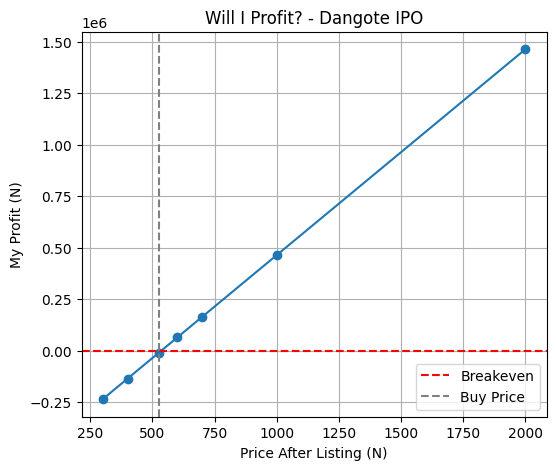

I need price to go above N535.50 to make profit because of fees


In [32]:
plt.figure(figsize=(6,5))
plt.plot(df["Future_prices"], df["Profit"], marker='o')
plt.axhline(0, color='red', linestyle='--', label='Breakeven')
plt.axvline(525, color='gray', linestyle='--', label='Buy Price')
plt.title("Will I Profit? - Dangote IPO")
plt.xlabel("Price After Listing (N)")
plt.ylabel("My Profit (N)")
plt.legend()
plt.grid(True)
plt.show()

# Find breakeven
breakeven = ipo_data["buy_price"] * (1 + fee)
print(f"I need price to go above N{breakeven:.2f} to make profit because of fees")

In [33]:
# Let's say refinery profit depend on oil price
# If Brent $60, margin is low. if $90, margin is high

oil_prices = [60, 70, 80, 90, 100]
for oil in oil_prices:
  # made up but logical rule
  if oil < 70:
    guess_future_price = 450
  elif oil < 85:
    guess_future_price = 500
  elif oil < 95:
    guess_future_price = 550
  else:
    guess_future_price = 600
  print(f"if oil is ${oil} -> i guess Dangote price might be N{guess_future_price}")

if oil is $60 -> i guess Dangote price might be N450
if oil is $70 -> i guess Dangote price might be N500
if oil is $80 -> i guess Dangote price might be N500
if oil is $90 -> i guess Dangote price might be N550
if oil is $100 -> i guess Dangote price might be N600


Conclusion: I invested N525000 for 1000 shares. I need price > N535.5 to profit. My model says if oil stays above 80, I have chance to profit, but if it drops below $70 I will lose. I will not invest money I cannot lose.

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2741/749495831.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latest_oil_price = float(brent["Close"].iloc[-1])
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12305 (\N{RIGHT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)



Last 5 days of Brent Oil:
Price            Close
Ticker            BZ=F
Date                  
2026-09-29  102.589996
2026-09-30  103.529999
2026-10-01  102.309998
2026-10-02  102.250000
2026-10-05  101.570000

Today Brent is: $101.57

--- My model now uses REAL data ---
Oil = $101.57 -> I guess 【entity-Dangote¦canonical_name=Dangote】 share = N800
Verdict: GOOD - high oil usually means high fuel prices


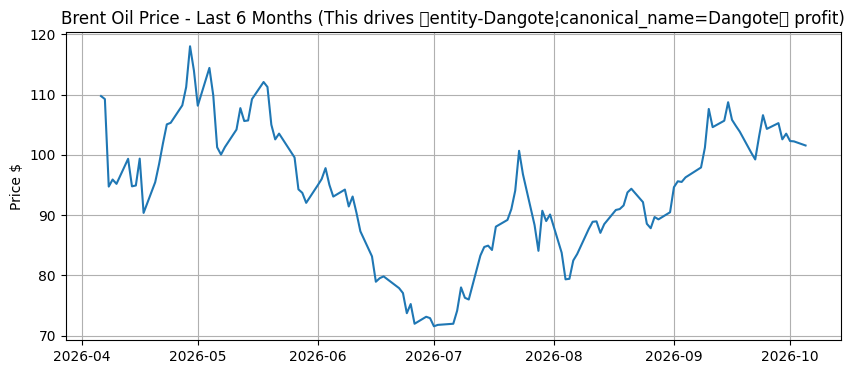

In [34]:
# Real World Data (Live Brent Oil Price)

# First time only - install the tool that gets stock/oil data
!pip install yfinance -q

import yfinance as yf

# BZ=F is the code for Brent Crude Oil on 【entity-Yahoo Finance¦canonical_name=Yahoo Finance】
print("Downloading real Brent oil price...")

brent = yf.download("BZ=F", period="6mo", interval="1d", auto_adjust=True)

# Show the last 5 days
print("\nLast 5 days of Brent Oil:")
print(brent.tail()[["Close"]])

# Get the latest price
latest_oil_price = float(brent["Close"].iloc[-1])
print(f"\nToday Brent is: ${latest_oil_price:.2f}")

# Now link it to your 【entity-Dangote¦canonical_name=Dangote】 guess
print("\n--- My model now uses REAL data ---")
if latest_oil_price < 70:
    guess = 450
    verdict = "RISKY - oil is low, refinery margin will be small"
elif latest_oil_price < 85:
    guess = 600
    verdict = "BASE CASE - decent"
else:
    guess = 800
    verdict = "GOOD - high oil usually means high fuel prices"

print(f"Oil = ${latest_oil_price:.2f} -> I guess 【entity-Dangote¦canonical_name=Dangote】 share = N{guess}")
print(f"Verdict: {verdict}")

# Plot it
plt.figure(figsize=(10,4))
plt.plot(brent["Close"])
plt.title("Brent Oil Price - Last 6 Months (This drives 【entity-Dangote¦canonical_name=Dangote】 profit)")
plt.ylabel("Price $")
plt.grid(True)
plt.show()

In [38]:
# Simple Fintech Model

def estimate_share_price(oil_price):
  if oil_price < 65:
    return 420
  elif oil_price < 75:
    return 520
  elif oil_price < 85:
    return 620
  elif oil_price < 95:
    return 720
  else:
    return 800
estimated_price = estimate_share_price(latest_oil_price)

my_shares = 1000
buy_price = 525
my_cost = my_shares * share_price
fee = 0.02

profit_at_estimate = estimated_price * my_shares - my_cost - (my_cost * fee)
return_percent = (profit_at_estimate / my_cost) * 100

print("="*50)
print("【entity-DANGOTE¦canonical_name=DANGOTE】 IPO - MY FIRST FINTECH MODEL")
print("="*50)
print(f"Live Brent Oil today:      ${latest_oil_price:.2f}")
print(f"My model estimates 【entity-Dangote¦canonical_name=DANGOTE】 will trade at: N{estimated_price}")
print(f"My investment:             N{my_cost} ({my_shares} shares @ N{buy_price})")
print(f"Estimated profit:          N{profit_at_estimate:.2f}")
print(f"Return:                    {return_percent:.1f}%")
print("-"*50)

if profit_at_estimate > 0:
    print("✅ MODEL SAYS: Potential profit (but not guaranteed)")
else:
    print("❌ MODEL SAYS: Potential loss at current oil price")

【entity-DANGOTE¦canonical_name=DANGOTE】 IPO - MY FIRST FINTECH MODEL
Live Brent Oil today:      $101.57
My model estimates 【entity-Dangote¦canonical_name=DANGOTE】 will trade at: N800
My investment:             N525000 (1000 shares @ N525)
Estimated profit:          N264500.00
Return:                    50.4%
--------------------------------------------------
✅ MODEL SAYS: Potential profit (but not guaranteed)


In [41]:
# What if oil changes tomorrow
oil_scenarios = [60, 70, 80, 90, 100]
share_gueses = [estimate_share_price(o) for o in oil_scenarios]
profits = [s * my_shares - my_cost - (my_cost * fee) for s in share_gueses]
returns = [p / my_cost * 100 for p in profits]

# Format each percentage in the list to 2 decimal places for clean printing
formatted_returns = [f"{r:.2f}%" for r in returns]
print(f"This is my returns list: {formatted_returns}")

This is my returns list: ['-22.00%', '-2.95%', '16.10%', '35.14%', '50.38%']


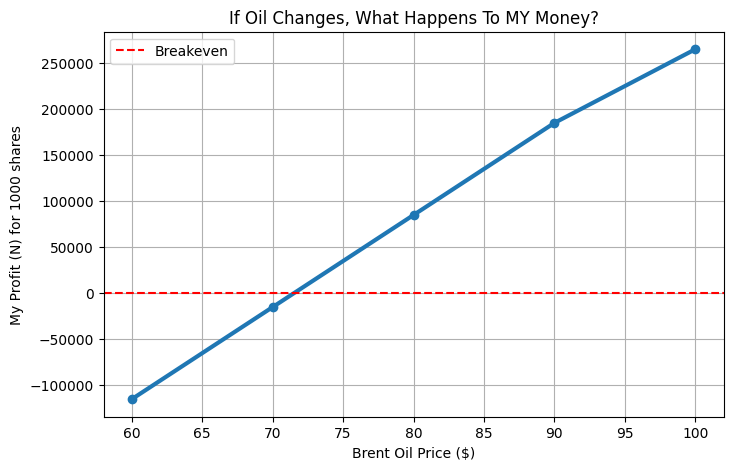

In [42]:
plt.figure(figsize=(8,5))
plt.plot(oil_scenarios, profits, marker='o', linewidth=3)
plt.axhline(0, color='red', linestyle='--', label='Breakeven')
plt.title("If Oil Changes, What Happens To MY Money?")
plt.xlabel("Brent Oil Price ($)")
plt.ylabel(f"My Profit (N) for {my_shares} shares")
plt.grid(True)
plt.legend()
plt.show()

In [45]:
risk_df = pd.DataFrame({
    "Oil_Price" : oil_scenarios,
    "Dangote_Price N" : share_gueses,
    "Profit" : profits,
    "Return%" : returns
})
risk_df


,Oil_Price,Dangote_Price N,Profit,Return%
0,60,420,-115500.0,-22.000000
1,70,520,-15500.0,-2.952381
2,80,620,84500.0,16.095238
3,90,720,184500.0,35.142857
4,100,800,264500.0,50.380952
